# Telco Customer Churn — Analysis & Predictive Modeling

## Project Overview
An end-to-end analysis of a telecom company's customer data, aimed at understanding the key drivers behind customer **churn** and building a predictive model that estimates the likelihood of a customer leaving — so the business can intervene early and reduce revenue loss.

**Notebook roadmap:**
1. Load and explore the raw data.
2. Exploratory Data Analysis (EDA) of demographic, service, and contract factors linked to churn.
3. Financial analysis (Monthly Charges, Total Charges, CLTV) and its relationship with churn.
4. Geographic analysis using KMeans clustering on customer coordinates to check whether location drives churn.
5. Data preparation (cleaning, encoding, balancing) for the machine learning stage.
6. Training an XGBoost model to predict churn and evaluating its performance.

## Power BI Dashboard
A full interactive dashboard (Executive Overview, Customer Demographics, Services & Contract Analysis, Financial Impact, Geographic Analysis, Churn Reasons) was built on top of the same dataset, and can be explored live here:

🔗 **[Telco Customer Churn Dashboard — Power BI Service](https://app.powerbi.com/links/JyLEMT_EZG?ctid=19fe7ed7-01ca-4ae6-9cb4-3d75b5264420&pbi_source=linkShare)**

---


## 0. Importing Libraries
All libraries used throughout the notebook are imported once here, up front, instead of being scattered across cells — this makes dependencies explicit and the notebook easier to rerun top-to-bottom.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import haversine_distances
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

from scipy.stats import chi2_contingency
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier


## 1. Data Loading
Load the customer Excel file and take a first look at it.

In [2]:
df = pd.read_excel("/content/Telco_customer_churn.xlsx")


In [3]:
df


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,2569-WGERO,1,United States,California,Landers,92285,"34.341737, -116.539416",34.341737,-116.539416,Female,...,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No,0,45,5306,NaN
7039,6840-RESVB,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.667815,-117.536183,Male,...,One year,Yes,Mailed check,84.80,1990.5,No,0,59,2140,NaN
7040,2234-XADUH,1,United States,California,Amboy,92304,"34.559882, -115.637164",34.559882,-115.637164,Female,...,One year,Yes,Credit card (automatic),103.20,7362.9,No,0,71,5560,NaN
7041,4801-JZAZL,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.167800,-116.864330,Female,...,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,59,2793,NaN


In [4]:
df.head()


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [5]:
df.tail()


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
7038,2569-WGERO,1,United States,California,Landers,92285,"34.341737, -116.539416",34.341737,-116.539416,Female,...,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No,0,45,5306,NaN
7039,6840-RESVB,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.667815,-117.536183,Male,...,One year,Yes,Mailed check,84.80,1990.5,No,0,59,2140,NaN
7040,2234-XADUH,1,United States,California,Amboy,92304,"34.559882, -115.637164",34.559882,-115.637164,Female,...,One year,Yes,Credit card (automatic),103.20,7362.9,No,0,71,5560,NaN
7041,4801-JZAZL,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.167800,-116.864330,Female,...,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,59,2793,NaN
7042,3186-AJIEK,1,United States,California,Apple Valley,92308,"34.424926, -117.184503",34.424926,-117.184503,Male,...,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No,0,38,5097,NaN


### Shape and Data Types
Checking the number of rows/columns, column names, and data types (numeric vs. object) to build a clear picture of the dataset before any analysis.

In [6]:
df.shape


(7043, 33)

In [7]:
df.columns


Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

In [8]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

### Descriptive Statistics
- `describe()` for numeric columns to check averages, spread, and potential outliers.
- `describe(include="object")` for text columns to see unique value counts and the most frequent category in each.
- Then we print the unique values of every categorical column to catch any inconsistent or unexpected entries.

In [9]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Count,7043.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
Zip Code,7043.0,93521.964646,1865.794555,90001.000000,92102.000000,93552.000000,95351.000000,96161.000000
Latitude,7043.0,36.282441,2.455723,32.555828,34.030915,36.391777,38.224869,41.962127
Longitude,7043.0,-119.798880,2.157889,-124.301372,-121.815412,-119.730885,-118.043237,-114.192901
Tenure Months,7043.0,32.371149,24.559481,0.000000,9.000000,29.000000,55.000000,72.000000
Monthly Charges,7043.0,64.761692,30.090047,18.250000,35.500000,70.350000,89.850000,118.750000
Churn Value,7043.0,0.265370,0.441561,0.000000,0.000000,0.000000,1.000000,1.000000
Churn Score,7043.0,58.699418,21.525131,5.000000,40.000000,61.000000,75.000000,100.000000
CLTV,7043.0,4400.295755,1183.057152,2003.000000,3469.000000,4527.000000,5380.500000,6500.000000


In [10]:
df.describe(include = "object").T


,count,unique,top,freq
CustomerID,7043,7043,3186-AJIEK,1
Country,7043,1,United States,7043
State,7043,1,California,7043
City,7043,1129,Los Angeles,305
Lat Long,7043,1652,"34.159534, -116.425984",5
Gender,7043,2,Male,3555
Senior Citizen,7043,2,No,5901
Partner,7043,2,No,3641
Dependents,7043,2,No,5416
Phone Service,7043,2,Yes,6361


In [11]:
for col in df.select_dtypes(include='object'):
    print(col)
    print(df[col].unique())
    print("-----------------------------------------------")


CustomerID
['3668-QPYBK' '9237-HQITU' '9305-CDSKC' ... '2234-XADUH' '4801-JZAZL'
 '3186-AJIEK']
-----------------------------------------------
Country
['United States']
-----------------------------------------------
State
['California']
-----------------------------------------------
City
['Los Angeles' 'Beverly Hills' 'Huntington Park' ... 'Standish' 'Tulelake'
 'Olympic Valley']
-----------------------------------------------
Lat Long
['33.964131, -118.272783' '34.059281, -118.30742' '34.048013, -118.293953'
 ... '40.346634, -120.386422' '41.813521, -121.492666'
 '39.191797, -120.212401']
-----------------------------------------------
Gender
['Male' 'Female']
-----------------------------------------------
Senior Citizen
['No' 'Yes']
-----------------------------------------------
Partner
['No' 'Yes']
-----------------------------------------------
Dependents
['No' 'Yes']
-----------------------------------------------
Phone Service
['Yes' 'No']
-----------------------------------

## 2. Target Variable — Churn Label
This is the most important column in the whole project — everything downstream is built around it.

In [12]:
df['Churn Label'].value_counts()


,count
Churn Label,
No,5174
Yes,1869


In [13]:
df['Churn Label'].value_counts(normalize=True) * 100


,proportion
Churn Label,
No,73.463013
Yes,26.536987


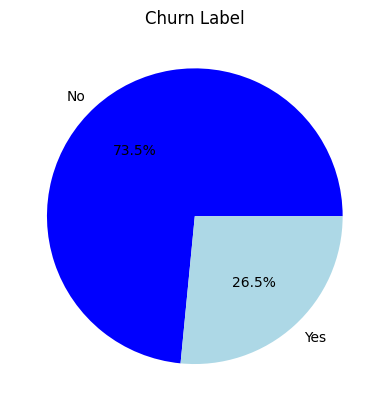

In [14]:
plt.pie(df['Churn Label'].value_counts(), labels=df['Churn Label'].value_counts().index, autopct='%1.1f%%',colors=['blue',"lightblue"])
plt.title('Churn Label')
plt.show()


> **Insight:** The overall churn rate is **26.5%** — roughly **one in four** customers has left the company. That's a high figure for the telecom industry, meaning even a small improvement in retention would have a significant financial impact.

## 3. Demographic Analysis
Examining how churn relates to customer demographics: gender, senior citizen status, partner status, and dependents.

In [15]:
pd.crosstab(df['Gender'], df['Churn Label'], normalize='index') * 100


Churn Label,No,Yes
Gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338


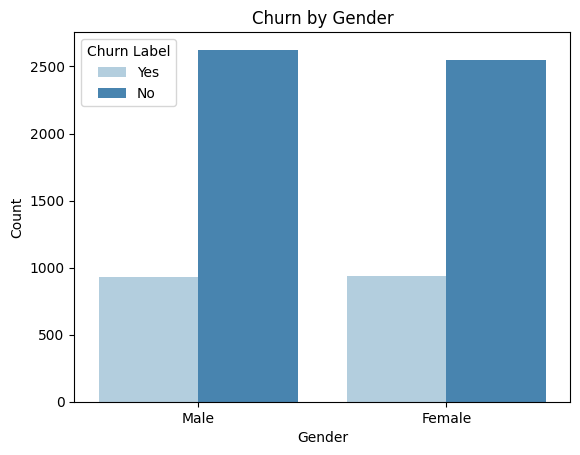

In [16]:
sns.countplot(data=df, x='Gender', hue='Churn Label', palette='Blues')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.title('Churn by Gender')
plt.show()


**Churn by Senior Citizen:**

In [17]:
df['Senior Citizen'].value_counts()


,count
Senior Citizen,
No,5901
Yes,1142


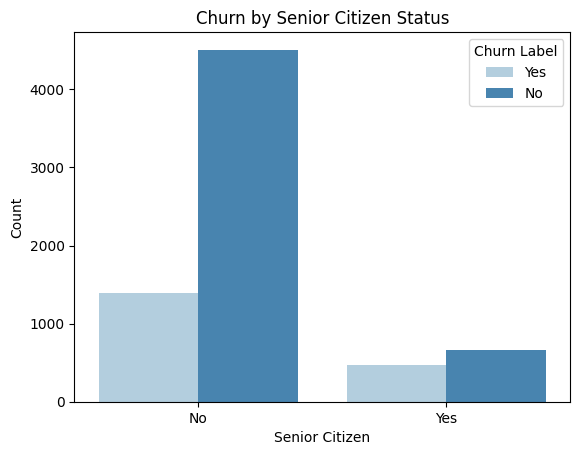

In [18]:
sns.countplot(data=df,x='Senior Citizen',hue='Churn Label',palette='Blues')
plt.xlabel('Senior Citizen')
plt.ylabel('Count')
plt.title('Churn by Senior Citizen Status')
plt.show()


**Churn by Partner Status:**

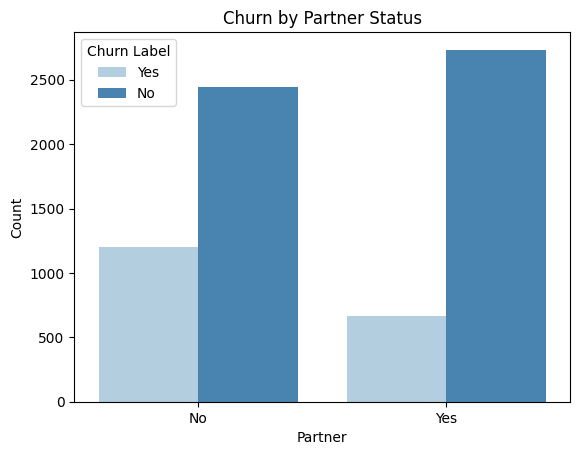

In [19]:
sns.countplot( data=df,x='Partner',hue='Churn Label',palette='Blues')
plt.xlabel('Partner')
plt.ylabel('Count')
plt.title('Churn by Partner Status')
plt.show()


**Churn by Dependents:**

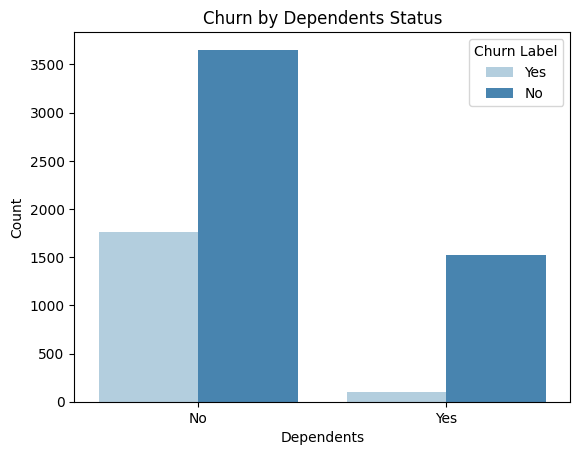

In [20]:
sns.countplot( data=df,x='Dependents',hue='Churn Label',palette='Blues')
plt.xlabel('Dependents')
plt.ylabel('Count')
plt.title('Churn by Dependents Status')
plt.show()


> **Insight:** Gender has no real effect on churn (rates are nearly identical across male/female). On the other hand, senior citizens, customers without a partner, and customers without dependents all show noticeably higher churn — which makes sense, since customers with family commitments tend to stay with the same provider for stability.

## 4. Tenure Analysis
How long a customer has stayed with the company (in months) is one of the strongest predictors of churn.

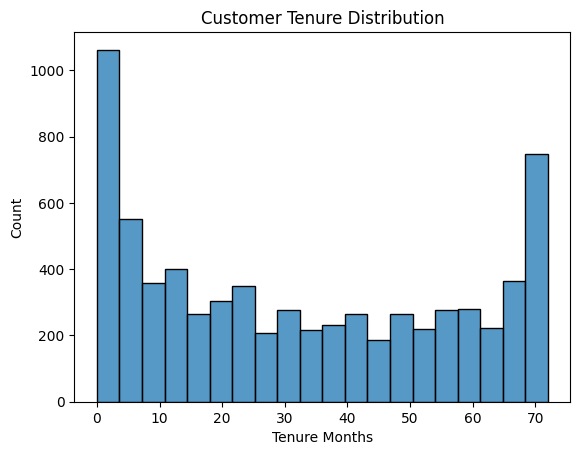

In [21]:
sns.histplot(
    data=df,
    x='Tenure Months',
    bins=20
)

plt.title('Customer Tenure Distribution')
plt.show()


/tmp/ipykernel_10540/28424753.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x='Churn Label',y='Tenure Months',palette='Blues')


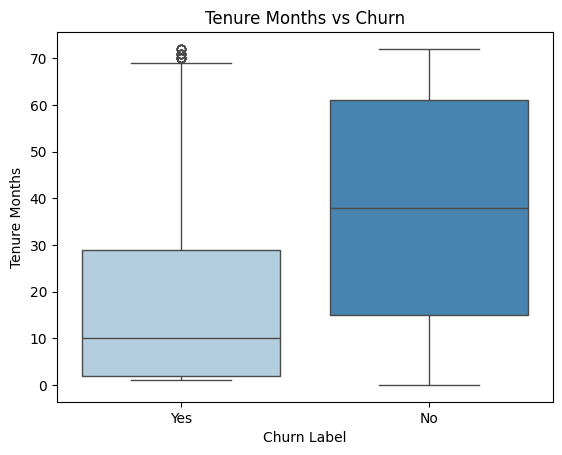

In [22]:
sns.boxplot(data=df,x='Churn Label',y='Tenure Months',palette='Blues')
plt.xlabel('Churn Label')
plt.ylabel('Tenure Months')
plt.title('Tenure Months vs Churn')
plt.show()


> **Insight:** Churned customers have a much lower average tenure than customers who stayed. Churn risk is highest in the first few months of the subscription, suggesting the early onboarding period is critical for building customer loyalty.

## 5. Internet Service, Contract Type & Payment Method
Studying the effect of internet service type, contract type, and payment method on a customer's decision to leave.

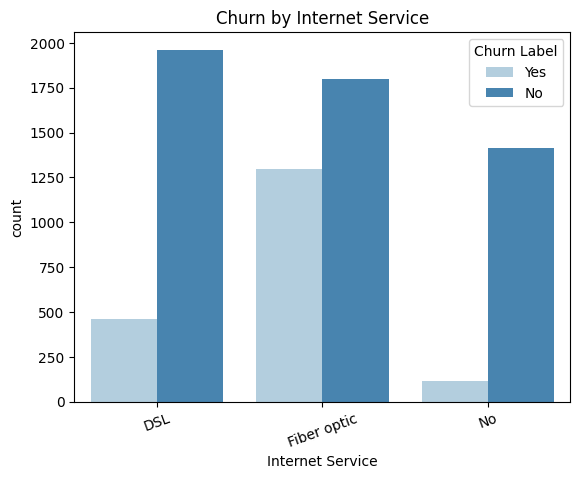

In [23]:
sns.countplot(data=df,x='Internet Service',hue='Churn Label',palette='Blues')
plt.title('Churn by Internet Service')
plt.xticks(rotation=20)
plt.show()


**Churn by Contract Type:**

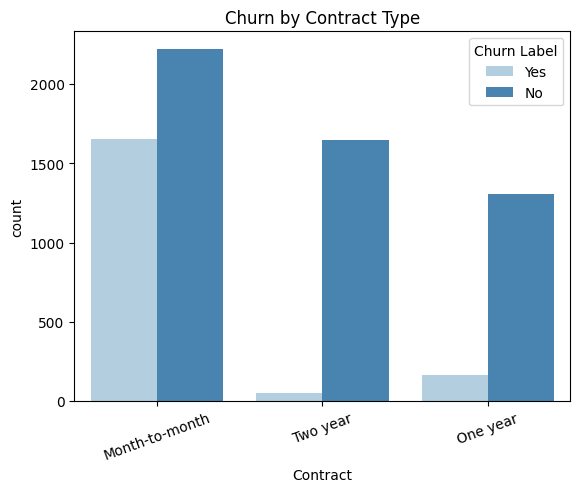

In [24]:
sns.countplot(data=df,x='Contract',hue='Churn Label',palette='Blues')
plt.title('Churn by Contract Type')
plt.xticks(rotation=20)
plt.show()


In [25]:
contract_churn = pd.crosstab(
    df['Contract'],
    df['Churn Label'],
    normalize='index'
) * 100

contract_churn


Churn Label,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


**Churn by Payment Method:**

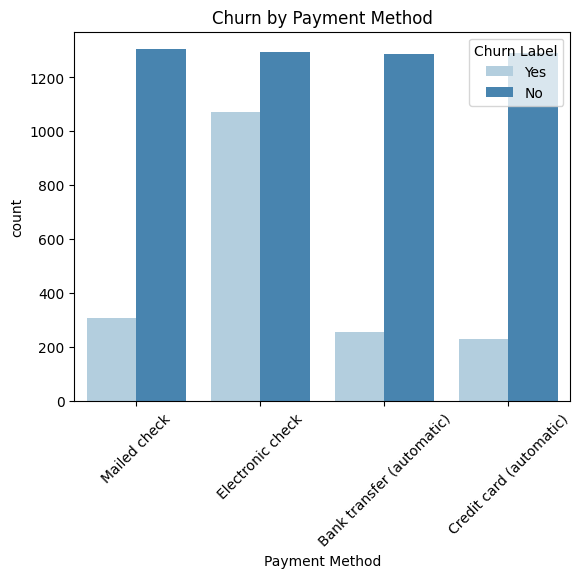

In [26]:
sns.countplot(data=df,x='Payment Method',hue='Churn Label',palette='Blues')
plt.title('Churn by Payment Method')
plt.xticks(rotation=45)
plt.show()


In [27]:
payment_churn = pd.crosstab(
    df['Payment Method'],
    df['Churn Label'],
    normalize='index'
) * 100

payment_churn


Churn Label,No,Yes
Payment Method,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


> **Insight:**
> - **Month-to-month** customers (no long-term commitment) churn at **42.7%**, versus only **11.3%** for one-year contracts and **2.8%** for two-year contracts. This is a massive gap and shows that **contractual commitment** is one of the strongest retention levers available.
> - **Electronic check** payment is linked to the highest churn rate (**45.3%**) compared to other methods (15–19%), which may reflect a customer segment that is less engaged with the service or more price-sensitive.

### Add-on Services
Does subscribing to services like online security, backup, tech support, and streaming reduce the likelihood of churn?

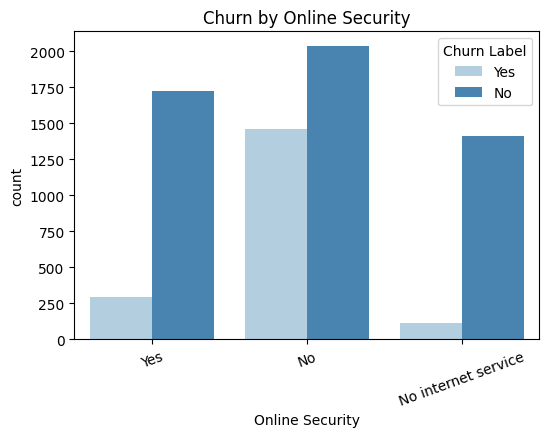

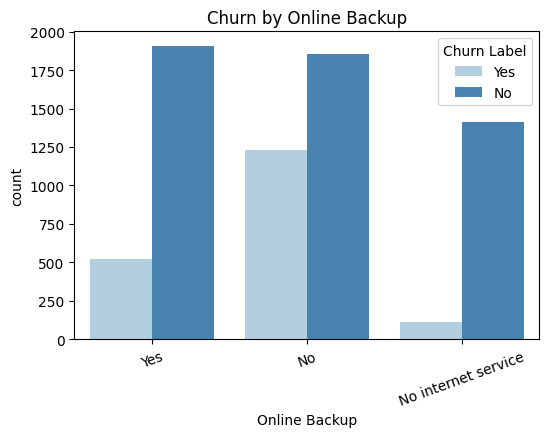

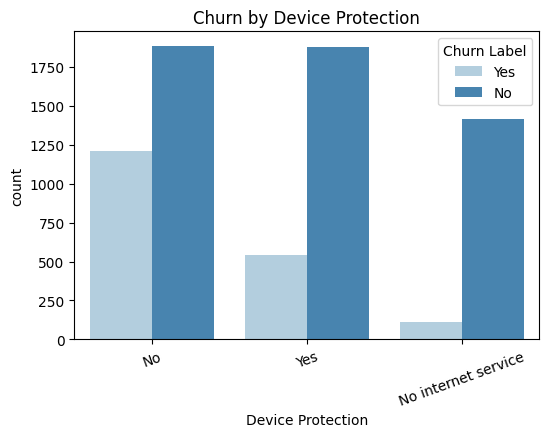

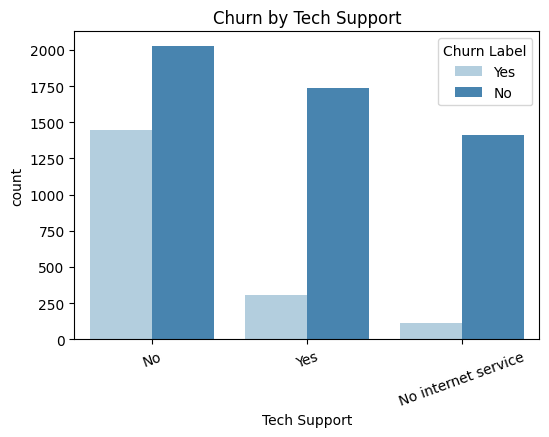

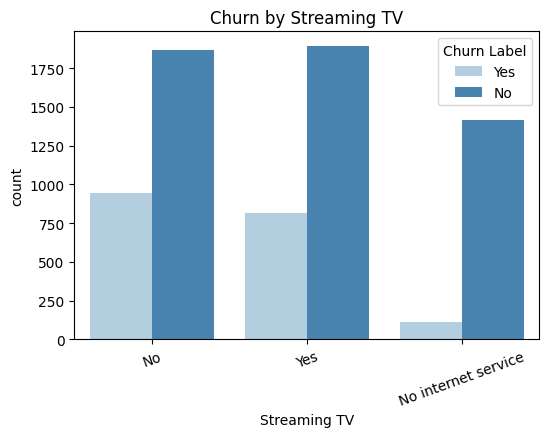

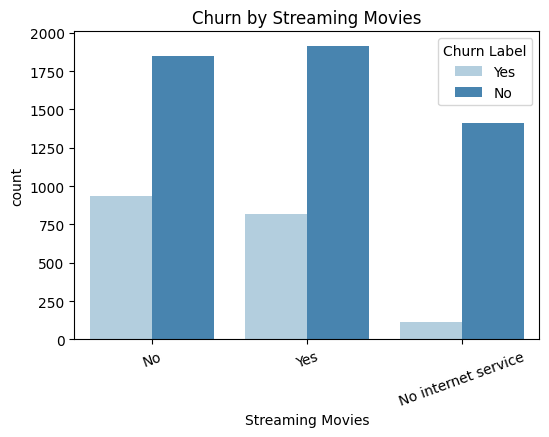

In [28]:
service_cols = [
    'Online Security',
    'Online Backup',
    'Device Protection',
    'Tech Support',
    'Streaming TV',
    'Streaming Movies'
]

for col in service_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=col, hue='Churn Label',palette="Blues")
    plt.title(f'Churn by {col}')
    plt.xticks(rotation=20)
    plt.show()


> **Insight:** Customers without add-on services like **Online Security** and **Tech Support** show noticeably higher churn. These services increase the customer's "switching cost" and make them more attached to the provider.

## 6. Financial Analysis
Examining the relationship between a customer's financial value (Monthly Charges, Total Charges, CLTV) and their decision to churn.

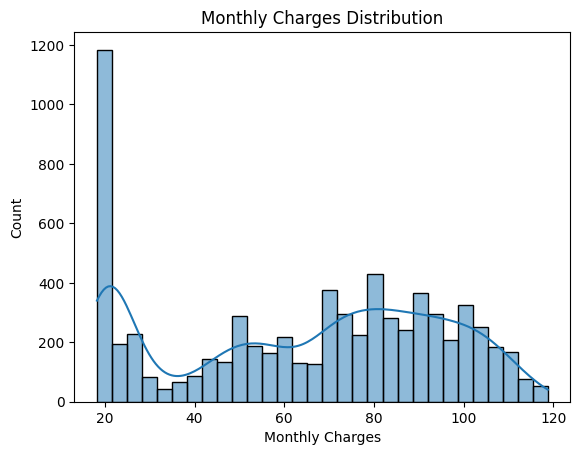

In [29]:
sns.histplot(
    data=df,
    x='Monthly Charges',
    bins=30,
    kde=True
)

plt.title('Monthly Charges Distribution')
plt.show()


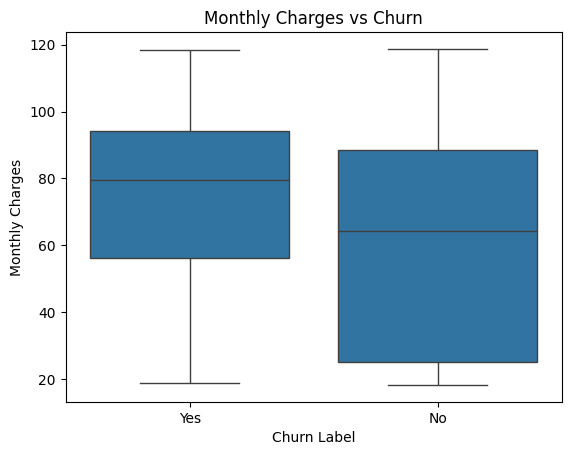

In [30]:
sns.boxplot(
    data=df,
    x='Churn Label',
    y='Monthly Charges'
)

plt.title('Monthly Charges vs Churn')
plt.show()


**Cleaning the Total Charges column:**
This column is stored as text (object) instead of numeric, so we convert it to a numeric type before it can be used in further analysis and plotting.

In [31]:
df['Total Charges'].value_counts()


,count
Total Charges,
20.2,11
,11
19.75,9
20.05,8
19.65,8
...,...
394.1,1
7589.8,1
905.55,1


In [32]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')


In [33]:
df['Total Charges'].dtypes


dtype('float64')

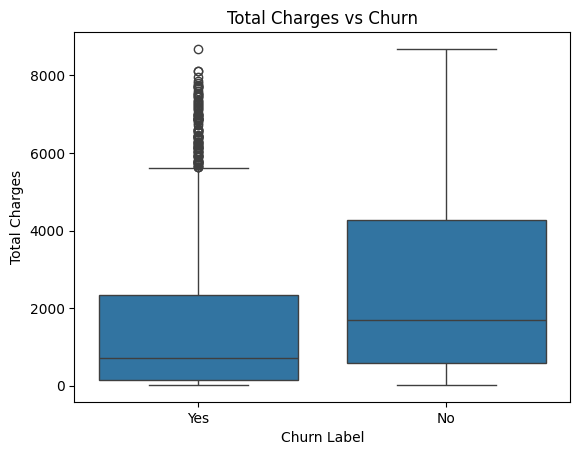

In [34]:
sns.boxplot(
    data=df,
    x='Churn Label',
    y='Total Charges'
)

plt.title('Total Charges vs Churn')
plt.show()


**Customer Lifetime Value (CLTV) vs. Churn:**

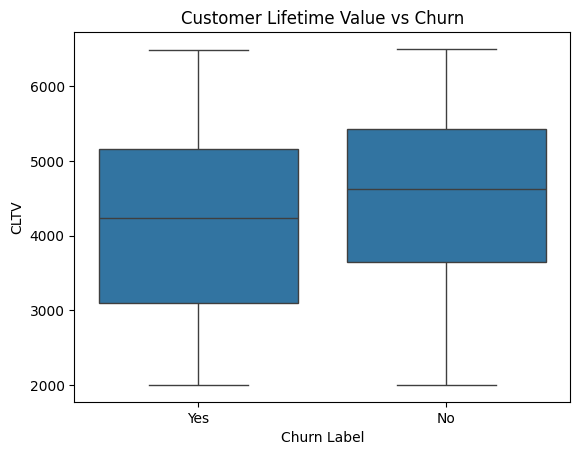

In [35]:
sns.boxplot(
    data=df,
    x='Churn Label',
    y='CLTV'
)

plt.title('Customer Lifetime Value vs Churn')
plt.show()


> **Insight:** Churned customers have, on average, **higher Monthly Charges** than retained customers — meaning the company is losing higher-paying customers, which amplifies the financial impact of churn. CLTV is naturally lower for churned customers due to their shorter relationship with the company.

## 7. Correlation Matrix
Checking the linear relationships between the key numeric variables.

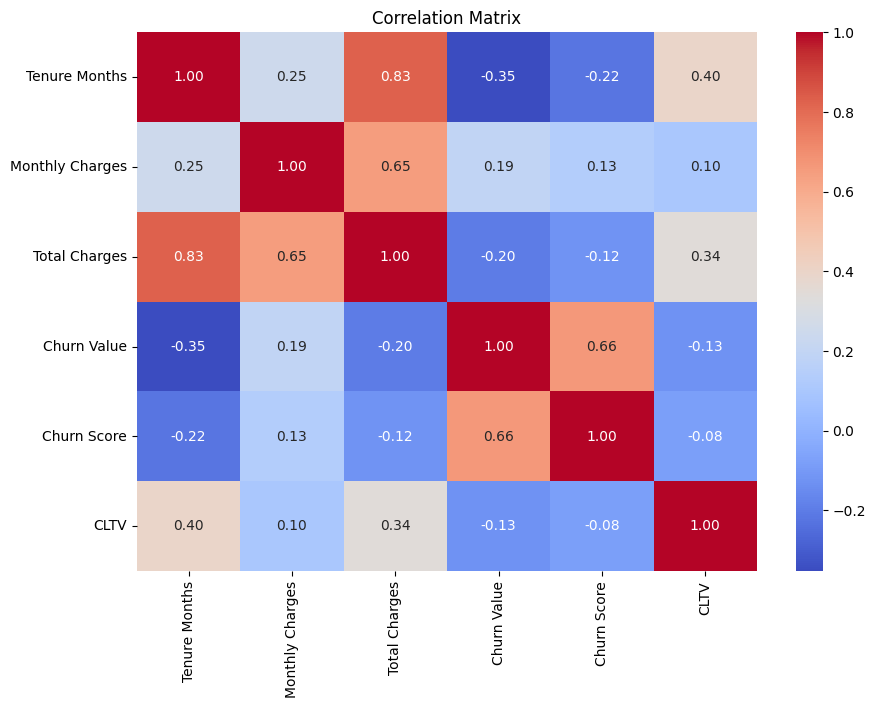

In [36]:
numeric_cols = [
    'Tenure Months',
    'Monthly Charges',
    'Total Charges',
    'Churn Value',
    'Churn Score',
    'CLTV'
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(10,7))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
)

plt.title('Correlation Matrix')
plt.show()


> **Insight:** `Churn Value` is negatively correlated with `Tenure Months` (the longer a customer stays, the less likely they are to churn), and positively correlated with `Churn Score` (a pre-computed churn-risk indicator already present in the dataset).

## 8. Segmented Churn Rate
Here we compute the actual churn rate (mean of `Churn Value`) within each category, rather than relying only on the visual counts from the previous charts.

In [37]:
churn_rate = (
    df.groupby('Contract')['Churn Value']
      .mean()
      .sort_values(ascending=False)
      * 100
)

churn_rate


,Churn Value
Contract,
Month-to-month,42.709677
One year,11.269518
Two year,2.831858


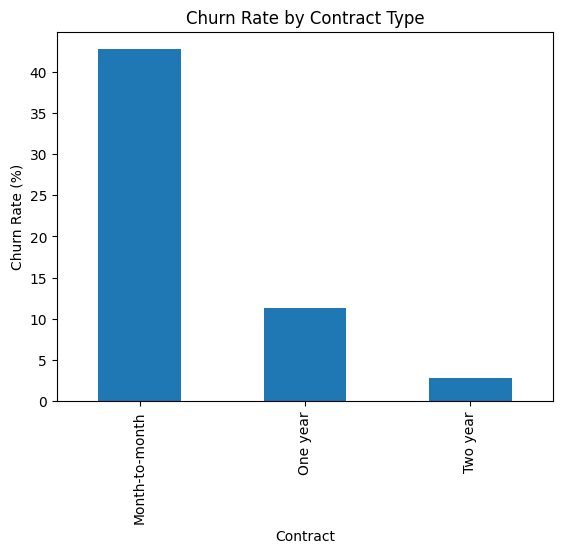

In [38]:
churn_rate.plot(kind='bar')

plt.title('Churn Rate by Contract Type')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Contract')
plt.show()


**Churn rate by internet service type:**

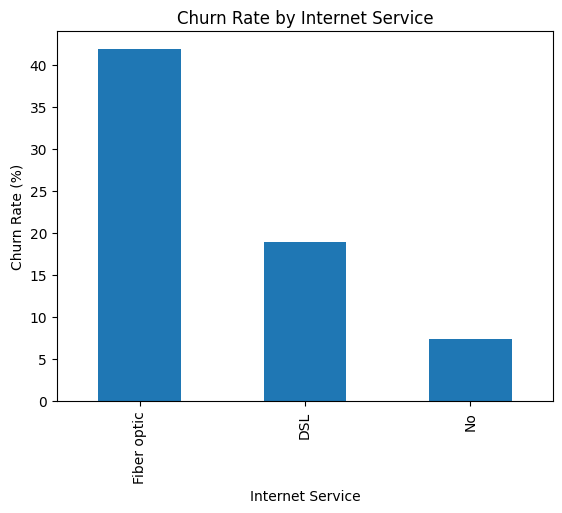

In [39]:
internet_churn = (
    df.groupby('Internet Service')['Churn Value']
      .mean()
      .sort_values(ascending=False)
      * 100
)

internet_churn.plot(kind='bar')

plt.title('Churn Rate by Internet Service')
plt.ylabel('Churn Rate (%)')
plt.show()


**Churn rate by payment method:**

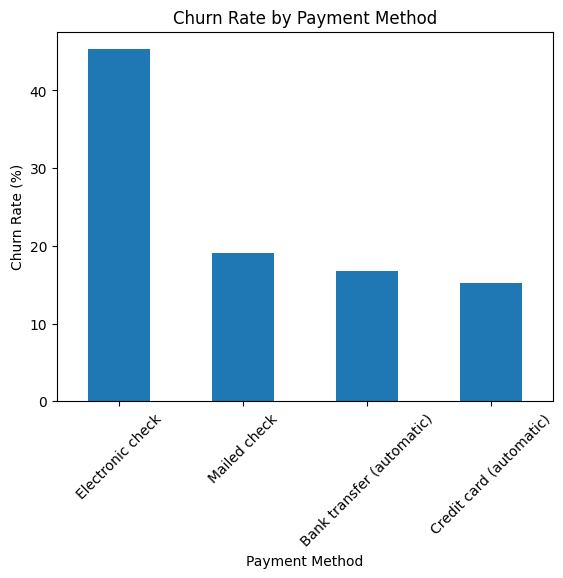

In [40]:
payment_churn = (
    df.groupby('Payment Method')['Churn Value']
      .mean()
      .sort_values(ascending=False)
      * 100
)

payment_churn.plot(kind='bar')

plt.title('Churn Rate by Payment Method')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45)
plt.show()


## 9. Churn Reasons
Analyzing the reasons cited by customers who actually churned, to understand *why* — not just *who*.

In [41]:
churned = df[df['Churn Value'] == 1]

churned['Churn Reason'].value_counts()


,count
Churn Reason,
Attitude of support person,192
Competitor offered higher download speeds,189
Competitor offered more data,162
Don't know,154
Competitor made better offer,140
Attitude of service provider,135
Competitor had better devices,130
Network reliability,103
Product dissatisfaction,102


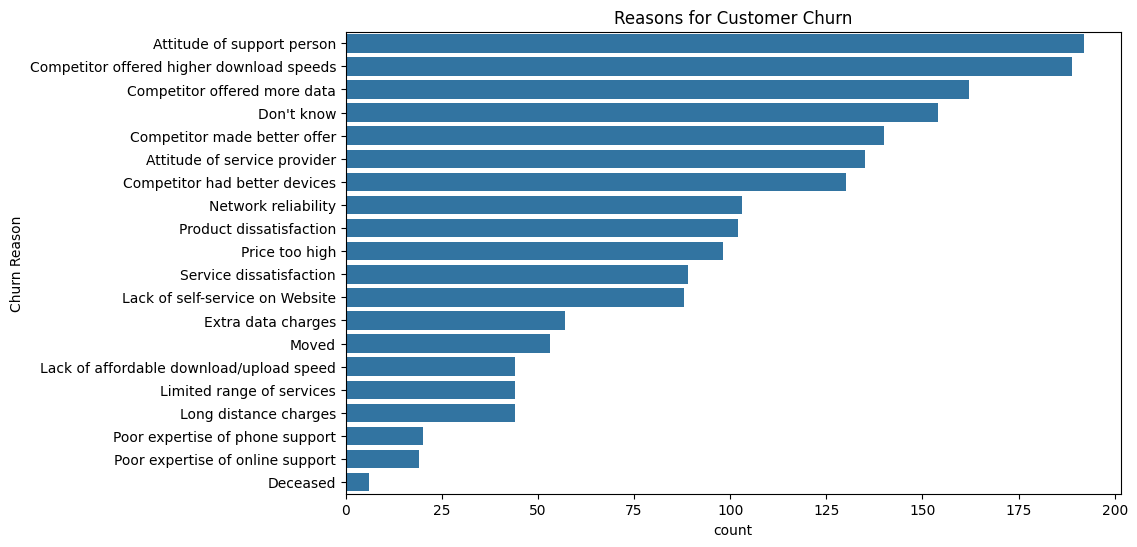

In [42]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=churned,
    y='Churn Reason',
    order=churned['Churn Reason'].value_counts().index
)

plt.title('Reasons for Customer Churn')
plt.show()


> **Insight:** The top reason for churn is **"Attitude of support person"** (192 cases), followed by competitive factors like **"Competitor offered higher download speeds"** and **"Competitor offered more data"**. This shows that a significant share of churn stems from the support experience itself, not just price or competition — a lever the company can act on directly.

## 10. City-level Churn Analysis

In [43]:
city_churn = (
    df.groupby('City')['Churn Value']
      .mean()
      .sort_values(ascending=False)
)


In [44]:
city_churn


,Churn Value
City,
Wrightwood,1.0
Tipton,1.0
Truckee,1.0
Twain,1.0
Johannesburg,1.0
...,...
La Crescenta,0.0
San Miguel,0.0
Montara,0.0


> **Note:** Some cities show extremely high churn rates (close to 100% in a few cases), but this is largely driven by very small sample sizes (10 customers or fewer per city). These rates are not statistically reliable and should be interpreted with caution.

## 11. Checking and Handling Missing Values

In [45]:
df.isna().sum()


,0
CustomerID,0
Count,0
Country,0
State,0
City,0
Zip Code,0
Lat Long,0
Latitude,0
Longitude,0
Gender,0


In [46]:
df[df['Total Charges'].isna()][
    ['CustomerID', 'Tenure Months', 'Monthly Charges', 'Total Charges', 'Churn Value']
]


,CustomerID,Tenure Months,Monthly Charges,Total Charges,Churn Value
2234,4472-LVYGI,0,52.55,NaN,0
2438,3115-CZMZD,0,20.25,NaN,0
2568,5709-LVOEQ,0,80.85,NaN,0
2667,4367-NUYAO,0,25.75,NaN,0
2856,1371-DWPAZ,0,56.05,NaN,0
4331,7644-OMVMY,0,19.85,NaN,0
4687,3213-VVOLG,0,25.35,NaN,0
5104,2520-SGTTA,0,20.00,NaN,0
5719,2923-ARZLG,0,19.70,NaN,0
6772,4075-WKNIU,0,73.35,NaN,0


In [47]:
df['Total Charges'] = df['Total Charges'].fillna(0)


In [48]:
df['Total Charges'].isna().sum()


np.int64(0)

> **Insight:** The missing values in `Total Charges` belong to brand-new customers (Tenure Months = 0) who haven't been billed yet, so filling them with 0 is both logical and statistically correct.

## 12. Geographic Clustering (KMeans)
The goal here is to group customers into geographic clusters based on their coordinates (Latitude, Longitude), to check whether specific regions have meaningfully higher churn, or whether the differences we saw at the city level are just noise.

### Finding the Optimal Number of Clusters (Elbow Method)

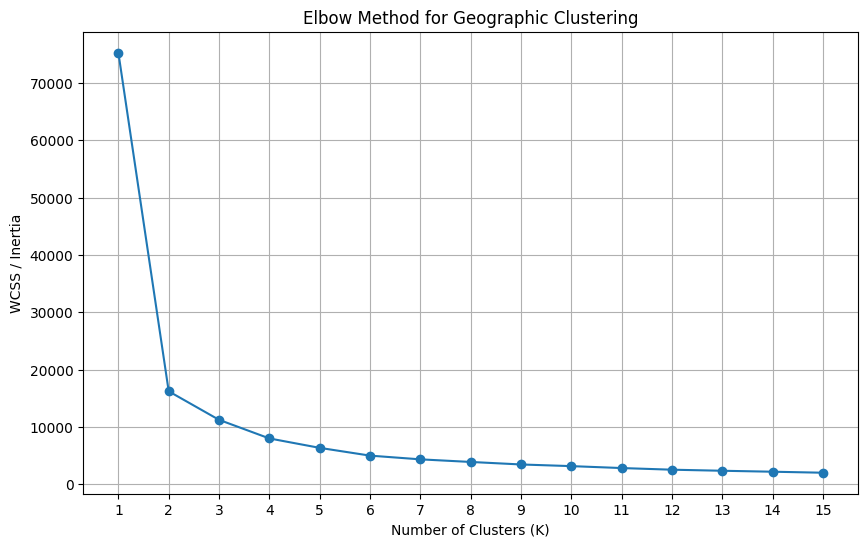

In [49]:
geo_features = df[['Latitude', 'Longitude']].copy()


wcss = []

for k in range(1, 16):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(geo_features)
    wcss.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, 16),
    wcss,
    marker='o'
)

plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS / Inertia')
plt.title('Elbow Method for Geographic Clustering')
plt.xticks(range(1, 16))
plt.grid(True)
plt.show()


> Based on the elbow curve, **K = 4** clusters was chosen as a reasonable balance between simplicity and cluster quality.

### Fitting KMeans and Assigning a Cluster to Each Customer

In [50]:
geo_features = df[['Latitude', 'Longitude']]

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df['Geographic_Cluster'] = kmeans.fit_predict(geo_features)


In [51]:
df


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason,Geographic_Cluster
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer,0
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved,0
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Yes,Electronic check,99.65,820.50,Yes,1,86,5372,Moved,0
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved,0
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,Competitor had better devices,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,2569-WGERO,1,United States,California,Landers,92285,"34.341737, -116.539416",34.341737,-116.539416,Female,...,Yes,Bank transfer (automatic),21.15,1419.40,No,0,45,5306,NaN,0
7039,6840-RESVB,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.667815,-117.536183,Male,...,Yes,Mailed check,84.80,1990.50,No,0,59,2140,NaN,0
7040,2234-XADUH,1,United States,California,Amboy,92304,"34.559882, -115.637164",34.559882,-115.637164,Female,...,Yes,Credit card (automatic),103.20,7362.90,No,0,71,5560,NaN,0
7041,4801-JZAZL,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.167800,-116.864330,Female,...,Yes,Electronic check,29.60,346.45,No,0,59,2793,NaN,0


In [52]:
df["Geographic_Cluster"].value_counts()


,count
Geographic_Cluster,
0,3035
1,2356
2,868
3,784


### Distance from the Geographic Center
Computing each customer's distance (in km) from the overall geographic center of the customer base, using the Haversine formula (which measures actual distance on the surface of the Earth rather than a straight line).

In [53]:
center_lat = df['Latitude'].mean()
center_lon = df['Longitude'].mean()

center = np.radians([[center_lat, center_lon]])

coordinates = np.radians(
    df[['Latitude', 'Longitude']].values
)

distances = haversine_distances(
    coordinates,
    center
)

df['Distance_From_Center'] = distances[:, 0] * 6371


In [54]:
df[
    [
        'CustomerID',
        'Latitude',
        'Longitude',
        'Geographic_Cluster',
        'Distance_From_Center'
    ]
].head(10)


,CustomerID,Latitude,Longitude,Geographic_Cluster,Distance_From_Center
0,3668-QPYBK,33.964131,-118.272783,0,292.762863
1,9237-HQITU,34.059281,-118.307420,0,281.925525
2,9305-CDSKC,34.048013,-118.293953,0,283.617422
3,7892-POOKP,34.062125,-118.315709,0,281.285424
4,0280-XJGEX,34.039224,-118.266293,0,285.694719
5,4190-MFLUW,34.066367,-118.309868,0,281.124964
6,8779-QRDMV,34.023810,-118.156582,0,292.166101
7,1066-JKSGK,34.066303,-118.435479,0,275.818514
8,6467-CHFZW,34.099869,-118.326843,0,277.104477
9,8665-UTDHZ,34.089953,-118.294824,0,279.485511


In [55]:
df[
    ['Geographic_Cluster', 'Distance_From_Center']
].isnull().sum()


,0
Geographic_Cluster,0
Distance_From_Center,0


### Visualizing the Clusters on a Map

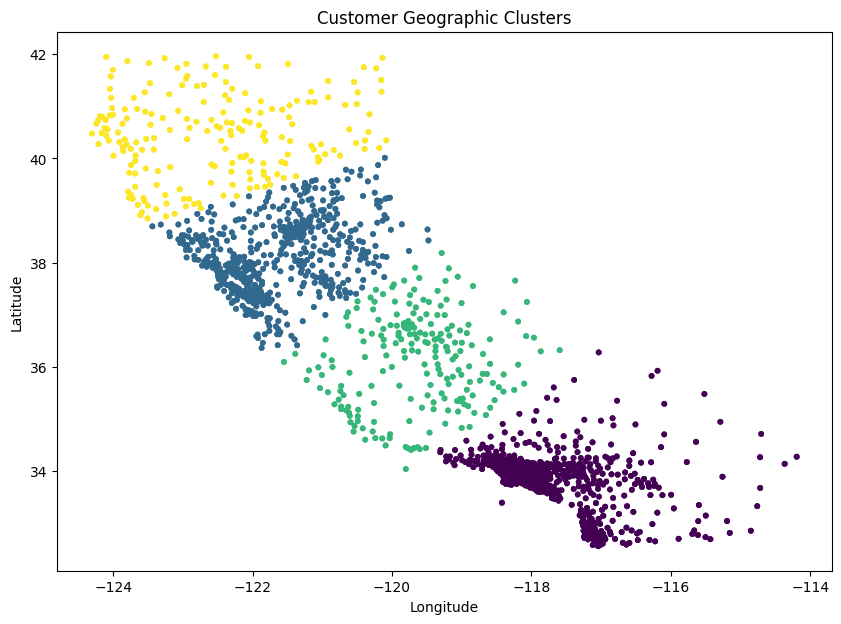

In [56]:
plt.figure(figsize=(10, 7))

plt.scatter(
    df['Longitude'],
    df['Latitude'],
    c=df['Geographic_Cluster'],
    s=10,
    alpha=0.6
)

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Customer Geographic Clusters')
plt.show()


### Churn Rate Within Each Cluster

In [57]:
cluster_churn = (
    df.groupby('Geographic_Cluster')['Churn Value']
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

cluster_churn


,Churn Value
Geographic_Cluster,
1,27.249576
0,26.820428
3,25.255102
2,24.769585


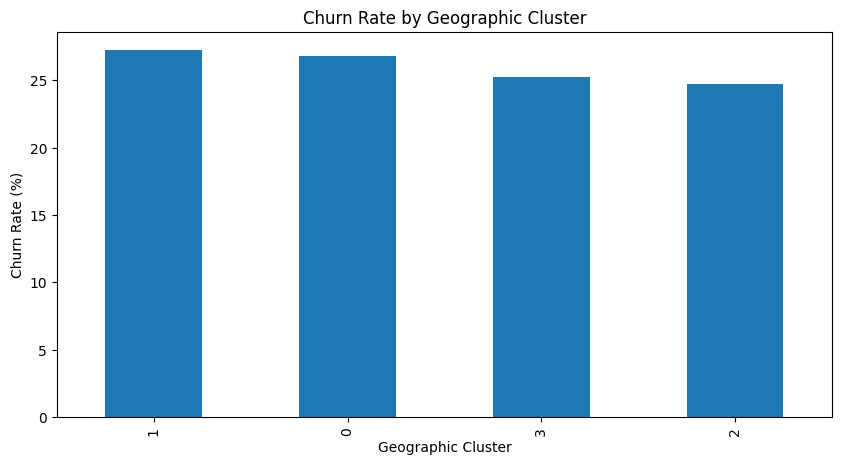

In [58]:
cluster_churn.plot(kind='bar', figsize=(10, 5))

plt.title('Churn Rate by Geographic Cluster')
plt.xlabel('Geographic Cluster')
plt.ylabel('Churn Rate (%)')
plt.show()


### Distance from Center vs. Churn

In [59]:
df.groupby('Churn Value')['Distance_From_Center'].mean()


,Distance_From_Center
Churn Value,
0,308.838162
1,311.100381


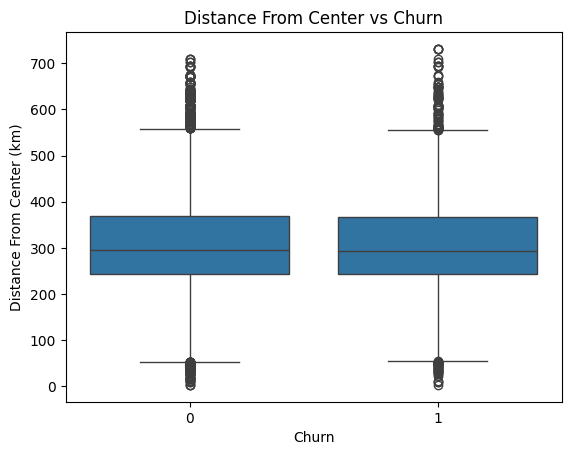

In [60]:
sns.boxplot(
    data=df,
    x='Churn Value',
    y='Distance_From_Center'
)

plt.title('Distance From Center vs Churn')
plt.xlabel('Churn')
plt.ylabel('Distance From Center (km)')
plt.show()


### Summary Table per Cluster

In [61]:
cluster_analysis = (
    df.groupby('Geographic_Cluster')['Churn Value']
      .agg(
          Customers='count',
          Churned='sum',
          Churn_Rate='mean'
      )
)

cluster_analysis['Churn_Rate'] *= 100

cluster_analysis


,Customers,Churned,Churn_Rate
Geographic_Cluster,,,
0,3035,814,26.820428
1,2356,642,27.249576
2,868,215,24.769585
3,784,198,25.255102


### Statistical Test (Chi-Square)
Checking whether the differences in churn rate between clusters are **statistically significant**, or just random noise.

In [62]:
contingency_table = pd.crosstab(
    df['Geographic_Cluster'],
    df['Churn Value']
)

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-Square:", chi2)
print("P-value:", p_value)


Chi-Square: 2.790393131986416
P-value: 0.425083821254162


> **Insight:** Churn rates across the 4 clusters are fairly close (24.8% – 27.2%), and the Chi-Square test confirms the difference is **not statistically significant** (P-value = 0.43, well above the 0.05 threshold). This means **geographic location is not a genuine driver of churn**, despite the apparent variation we saw at the individual-city level (which, as noted, is mostly a small-sample-size artifact).

## 13. Data Preparation for Machine Learning
With the exploratory analysis complete, we now prepare the data for training a classification model.

In [63]:
df.columns


Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason', 'Geographic_Cluster',
       'Distance_From_Center'],
      dtype='object')

In [64]:
df.isna().sum()


,0
CustomerID,0
Count,0
Country,0
State,0
City,0
Zip Code,0
Lat Long,0
Latitude,0
Longitude,0
Gender,0


In [65]:
df.dtypes


,0
CustomerID,object
Count,int64
Country,object
State,object
City,object
Zip Code,int64
Lat Long,object
Latitude,float64
Longitude,float64
Gender,object


### Dropping Columns Not Useful for the Model
We remove columns that are:
- Unique identifiers with no predictive value (`CustomerID`, `Lat Long`).
- Fine-grained geographic fields that already served their purpose in the analysis above (`Country`, `State`, `City`, `Latitude`, `Longitude`, `Count`, `Zip Code`).
- Columns that leak the target variable itself (data leakage) — `Churn Reason`, `Churn Score`, `Churn Value`, `CLTV` are all derived from or directly tied to the churn event, so keeping them would let the model "cheat" by seeing the answer before predicting it.

In [66]:
df = df.drop(['Country','State','Count','Zip Code','Churn Reason','City','Churn Score','Churn Value','CLTV','CustomerID','Lat Long',
                  'Latitude','Longitude'], axis = 1)


### Converting the Target Variable to Numeric
Mapping `Churn Label` from `Yes/No` to `1/0` so it can be used as a valid input for classification models.

In [68]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Gender                7043 non-null   object 
 1   Senior Citizen        7043 non-null   object 
 2   Partner               7043 non-null   object 
 3   Dependents            7043 non-null   object 
 4   Tenure Months         7043 non-null   int64  
 5   Phone Service         7043 non-null   object 
 6   Multiple Lines        7043 non-null   object 
 7   Internet Service      7043 non-null   object 
 8   Online Security       7043 non-null   object 
 9   Online Backup         7043 non-null   object 
 10  Device Protection     7043 non-null   object 
 11  Tech Support          7043 non-null   object 
 12  Streaming TV          7043 non-null   object 
 13  Streaming Movies      7043 non-null   object 
 14  Contract              7043 non-null   object 
 15  Paperless Billing    

In [69]:
df['Churn Label'].replace(to_replace='Yes', value=1, inplace=True)
df['Churn Label'].replace(to_replace='No',  value=0, inplace=True)


/tmp/ipykernel_10540/1270321872.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Churn Label'].replace(to_replace='Yes', value=1, inplace=True)
/tmp/ipykernel_10540/1270321872.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, 

### Encoding Categorical Columns (Label Encoding)
The remaining text columns (e.g. Gender, Contract, Payment Method...) need to be converted to numbers so the model can process them.

In [70]:
def encode_data(dataframe_series):
    if dataframe_series.dtype=='object':
        dataframe_series = LabelEncoder().fit_transform(dataframe_series)
    return dataframe_series


In [73]:
df = df.apply(lambda x: encode_data(x))
df.head()


,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Geographic_Cluster,Distance_From_Center
0,1,0,0,0,2,1,0,0,2,2,...,0,0,0,1,3,53.85,108.15,1,0,292.762863
1,0,0,0,1,2,1,0,1,0,0,...,0,0,0,1,2,70.70,151.65,1,0,281.925525
2,0,0,0,1,8,1,2,1,0,0,...,2,2,0,1,2,99.65,820.50,1,0,283.617422
3,0,0,1,1,28,1,2,1,0,0,...,2,2,0,1,2,104.80,3046.05,1,0,281.285424
4,1,0,0,1,49,1,2,1,0,2,...,2,2,0,1,0,103.70,5036.30,1,0,285.694719


### Target Variable Distribution After Encoding

In [74]:
df.groupby('Churn Label')['Churn Label'].count()


,Churn Label
Churn Label,
0,5174
1,1869


### Correlation with the Target After Encoding
Re-checking which features are most strongly correlated with churn now that all columns are numeric.

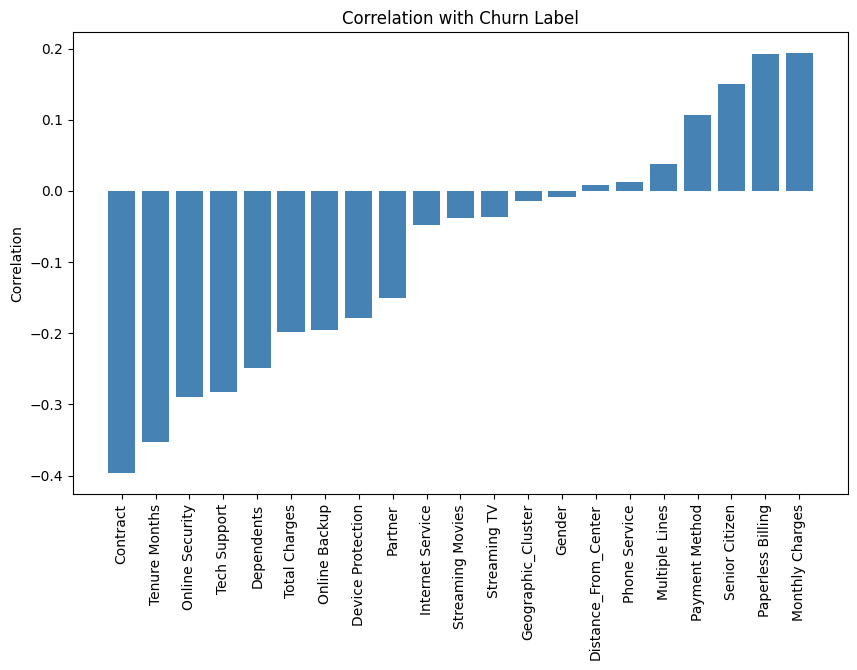

In [83]:
corr = df.corr(numeric_only=True)['Churn Label'].drop('Churn Label').sort_values()

plt.figure(figsize=(10, 6))
plt.bar(corr.index, corr.values, color='steelblue')
plt.xticks(rotation=90)
plt.ylabel('Correlation')
plt.title('Correlation with Churn Label')
plt.show()


## 14. Handling Class Imbalance and Splitting the Data
The churn rate is only **26.5%**, meaning there's a clear class imbalance between the two labels (Yes/No). If we train on this as-is, the model will tend to predict "No" most of the time and under-detect actual churn cases.

We use **SMOTE** (Synthetic Minority Over-sampling Technique) to generate synthetic samples for the minority class (Churn = Yes) and balance the class distribution before training.

In [84]:
over = SMOTE(sampling_strategy = 1)

x = df.drop("Churn Label", axis = 1).values
y = df['Churn Label'].values


In [85]:
x,y = over.fit_resample(x,y)


### Splitting the Data into Train and Test Sets (80% / 20%)

In [87]:
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state =2, test_size = 0.2)

print("X_train:", x_train.shape)
print("X_test :", x_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


X_train: (8278, 21)
X_test : (2070, 21)
y_train: (8278,)
y_test : (2070,)


## 15. Building and Evaluating the Prediction Model (XGBoost)

### A Reusable Training & Evaluation Function
A single, reusable function that trains any given model, plots the confusion matrix (with both counts and percentages), and prints the key performance metrics (ROC AUC, Accuracy, Precision, Recall, F1-score).

In [96]:
def model(method, x_train, y_train, x_test, y_test):
    # Train the model
    method.fit(x_train, y_train)

    # Make predictions on test data and calculate confusion matrix
    predictions = method.predict(x_test)
    c_matrix = confusion_matrix(y_test, predictions)

    # Calculate label percentages and create label strings with counts and percentages
    percentages = (c_matrix / np.sum(c_matrix, axis=1)[:, np.newaxis]).round(2) * 100
    labels = [[f"{c_matrix[i, j]} ({percentages[i, j]:.2f}%)" for j in range(c_matrix.shape[1])] for i in range(c_matrix.shape[0])]
    labels = np.asarray(labels)

    # Plot confusion matrix with labeled counts and percentages
    sns.heatmap(c_matrix, annot=labels, fmt='', cmap='Blues')

    # Evaluate model performance and print results
    print("ROC AUC: ", '{:.2%}'.format(roc_auc_score(y_test, predictions)))
    print("Model accuracy: ", '{:.2%}'.format(accuracy_score(y_test, predictions)))
    print(classification_report(y_test, predictions))


### Defining the XGBoost Model

In [97]:
xgb = XGBClassifier(learning_rate= 0.01,max_depth = 3,n_estimators = 1000)


### Training the Model and Reviewing Results

ROC AUC:  86.87%
Model accuracy:  86.86%
              precision    recall  f1-score   support

           0       0.88      0.86      0.87      1049
           1       0.86      0.88      0.87      1021

    accuracy                           0.87      2070
   macro avg       0.87      0.87      0.87      2070
weighted avg       0.87      0.87      0.87      2070



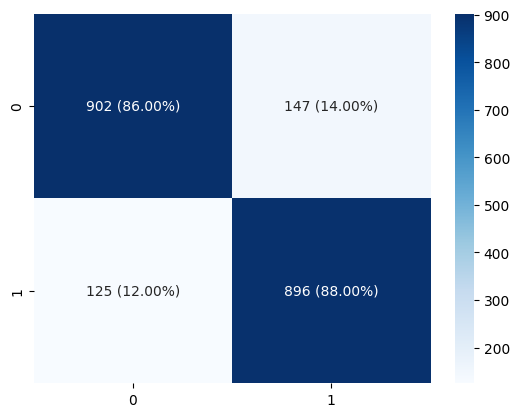

In [98]:
model(xgb,x_train,y_train,x_test,y_test)


> **Insight — Model Results:**
> - **Accuracy:** 86.86%
> - **ROC AUC:** 86.87%
> - **Precision / Recall / F1** are well balanced across both classes (0.86–0.88 for each), thanks to using SMOTE to balance the training data.
>
> The model performs strongly and reliably, and can be used in practice to rank customers by churn probability (a "Risk Score") — exactly like the `Risk Score` column shown on the **Financial Impact** page of the dashboard, so the Retention Team can prioritize the highest-risk customers first.

---
## Key Takeaways

1. **Month-to-month contracts are the strongest risk factor** — churn reaches 42.7%, versus under 3% for two-year contracts. Encouraging customers into longer contracts through discounts or added perks can directly reduce churn.
2. **Customer support experience is a leading driver of churn** — "Attitude of support person" is the most cited reason, ahead of competitor offers, pointing to a clear opportunity to improve support team training and quality.
3. **Electronic check payments correlate with the highest churn rate** (45.3%) — worth investigating further and potentially encouraging automatic payment methods instead.
4. **Geographic location is not a statistically significant driver of churn** (P-value = 0.43) — retention resources are better targeted by contract type and service usage rather than by region.
5. **The XGBoost model achieves 86.9% accuracy** and is suitable for real-world use in identifying high-risk customers before they actually churn.

For a full interactive exploration of these results, see the dashboard:
🔗 **[Telco Customer Churn Dashboard — Power BI Service](https://app.powerbi.com/links/JyLEMT_EZG?ctid=19fe7ed7-01ca-4ae6-9cb4-3d75b5264420&pbi_source=linkShare)**

📄 **[View Key Insights & Recommendations (PDF)](./Telco_Churn_Insights_Recommendations.pdf)**

